<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/10_exgaussian_default_priors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 10 — Priors that ignore the link function

Repeat notebook 9's ex-Gaussian model, but choose the scale and tail priors the way a modeler might who has not checked what they imply once transformed through the log link.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


D:\Repositories\BayesShortCourse\tmp\colabenv\Scripts\python.exe: No module named pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import xarray as xr
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every model in this sequence keeps `Days` on its natural scale (no centering). The intercept prior is therefore a prior on baseline reaction time rather than reaction time at the average deprivation day.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


In [4]:
# Plotting helpers (presentation only). Every plot uses the golf-notebook grammar:
# orange mean line, blue 50% and 90% HDI bands, black observed points.
DRAW_COLOR = "#12505e"  # darker shade of the band colour C0
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}
PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(sleep[["Subject", "Days"]], names=["participant", "day"]),
    "obs_id",
)

def add_interval_legend(target, line_label="mean", draws_label=None):
    """Compact one-row legend above an axis or above a whole panel grid."""
    handles = [
        Line2D([0], [0], color="C1", lw=1.6, label=line_label),
        Patch(facecolor="C0", alpha=0.9, label="50% HDI"),
        Patch(facecolor="C0", alpha=0.28, label="90% HDI"),
    ]
    if draws_label:
        handles.append(Line2D([0], [0], color=DRAW_COLOR, lw=0.9, label=draws_label))
    handles.append(Line2D([0], [0], marker="o", linestyle="none", color="black",
                          markersize=4.5, label="observed"))
    style = dict(ncols=len(handles), fontsize=8, handlelength=1.4, handletextpad=0.45,
                 columnspacing=0.9, frameon=False)
    if isinstance(target, plt.Figure):
        target.legend(handles=handles, loc="outside upper left", **style)
    else:
        target.legend(handles=handles, loc="lower left", bbox_to_anchor=(0, 1.01),
                      borderaxespad=0, **style)

def plot_population(dt, var, group="posterior"):
    """Single-panel trend of `var` against days, with all 144 raw observations."""
    pc = azp.plot_lm(
        dt, x="days", y=var, y_obs="Reaction", group=group, plot_dim="obs_id",
        ci_prob=(0.50, 0.90), ci_kind="hdi", point_estimate="mean", smooth=False,
        figure_kwargs={"figsize": (7, 4)}, visuals=LM_VISUALS,
    )
    ax = plt.gca()
    ax.set(xlabel="Days of sleep deprivation", ylabel="Reaction time (ms)")
    add_interval_legend(ax)
    return pc

def plot_participants(dt, group, var):
    """One panel per participant: bands for `var` against days, with that participant's data."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")
    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })
    pc = azp.plot_lm(
        panels, x="days", y=var, y_obs="Reaction", group=group, plot_dim="day",
        ci_prob=(0.50, 0.90), ci_kind="hdi", point_estimate="mean", smooth=False,
        cols=["participant"], col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )
    fig = pc.viz["figure"].item()
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")
    add_interval_legend(fig)
    return pc

In [5]:
participants = sorted(sleep["Subject"].unique(), key=int)
participant_idx = sleep["Subject"].map({p: i for i, p in enumerate(participants)}).to_numpy()

## 10.1 Naive log-link priors

What happens if the scale and tail priors are guessed directly on the link scale, without translating them into milliseconds first?

Everything about the mean structure (`intercept`, `slope`, and their participant terms) is unchanged from notebook 9. Only the priors for the log-linear scale (`sigma_intercept`) and tail (`nu_intercept`) change, to $N(0,5)$ — a prior that looks harmlessly vague written down, but on the millisecond scale spans roughly 0.01 ms to 150{,}000 ms.

In [6]:
coords = {"obs_id": np.arange(len(sleep)), "participant": participants}

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")
    pidx = pm.Data("participant_idx", participant_idx, dims="obs_id")

    intercept = pm.Normal("intercept", mu=250, sigma=100)
    slope = pm.Normal("slope", mu=0, sigma=20)

    participant_intercept_sd = pm.Exponential("participant_intercept_sd", lam=0.04)
    participant_intercept_z = pm.Normal("participant_intercept_z", 0, 1, dims="participant")
    participant_intercept = pm.Deterministic(
        "participant_intercept",
        participant_intercept_sd * participant_intercept_z,
        dims="participant",
    )

    participant_slope_sd = pm.Exponential("participant_slope_sd", lam=0.10)
    participant_slope_z = pm.Normal("participant_slope_z", 0, 1, dims="participant")
    participant_slope = pm.Deterministic(
        "participant_slope",
        participant_slope_sd * participant_slope_z,
        dims="participant",
    )

    # Naive: a plausible-looking N(0, 5) on the *log* scale, not translated
    # into milliseconds.
    sigma_intercept = pm.Normal("sigma_intercept", mu=0, sigma=5)
    participant_sigma_sd = pm.Exponential("participant_sigma_sd", lam=0.20)
    participant_sigma_z = pm.Normal("participant_sigma_z", 0, 1, dims="participant")
    participant_sigma = pm.Deterministic(
        "participant_sigma",
        participant_sigma_sd * participant_sigma_z,
        dims="participant",
    )
    residual_scale = pm.Deterministic(
        "residual_scale",
        pm.math.exp(sigma_intercept + participant_sigma),
        dims="participant",
    )

    nu_intercept = pm.Normal("nu_intercept", mu=0, sigma=5)
    tail = pm.Deterministic("tail", pm.math.exp(nu_intercept))

    population_mu = pm.Deterministic(
        "population_mu", intercept + slope * days, dims="obs_id"
    )
    mu = pm.Deterministic(
        "mu",
        population_mu
        + participant_intercept[pidx]
        + participant_slope[pidx] * days,
        dims="obs_id",
    )
    sigma = pm.Deterministic("sigma", residual_scale[pidx], dims="obs_id")

    mean_rt = pm.Deterministic("mean_rt", mu + tail, dims="obs_id")
    population_mean_rt = pm.Deterministic(
        "population_mean_rt", population_mu + tail, dims="obs_id"
    )

    pm.ExGaussian(
        "Reaction",
        mu=mu,
        sigma=sigma,
        nu=tail,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

Before fitting, ask what reaction times the priors make plausible. Each panel is one participant. The bands are the prior predictive distribution of a single new reaction-time measurement on each day. The black points are that participant's data, shown only as a reference: they do not condition the prior.

Sampling: [Reaction, intercept, nu_intercept, participant_intercept_sd, participant_intercept_z, participant_sigma_sd, participant_sigma_z, participant_slope_sd, participant_slope_z, sigma_intercept, slope]


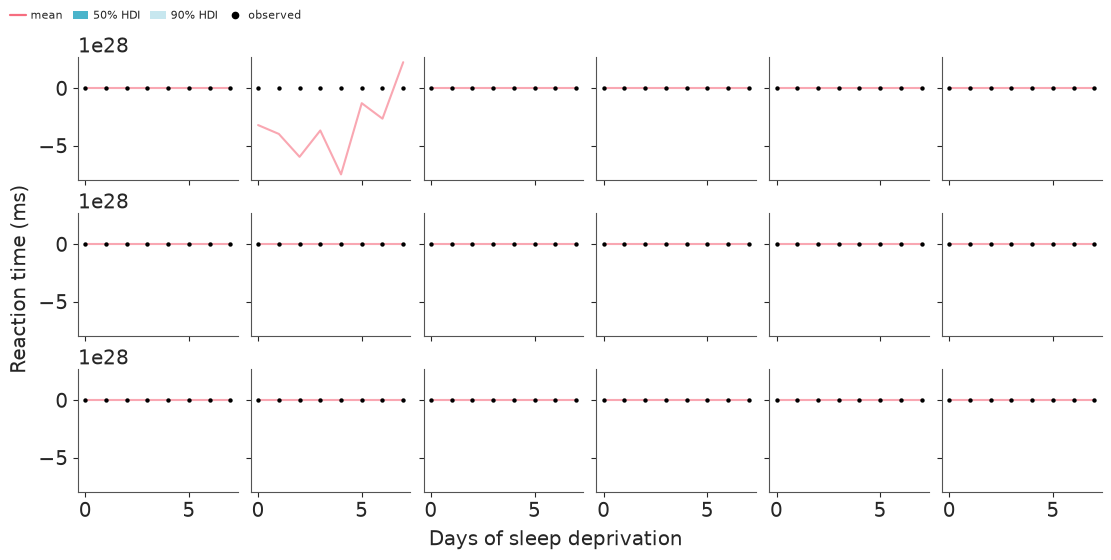

In [7]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500, var_names=["Reaction"], random_seed=RANDOM_SEED
    )

plot_participants(prior, "prior_predictive", "Reaction")
plt.show()

## 10.2 Posterior changes under naive priors

Which posterior features change when notebook 9's informed scale and tail priors are replaced by unscaled ones?

Do not interpret the fit until the sampler diagnostics are acceptable: no divergences, R-hat ≤ 1.01, and bulk and tail ESS in the hundreds or more.

In [8]:
with model:
    idata = pm.sample(
        draws=1000, tune=2000, chains=4, target_accept=0.95, random_seed=RANDOM_SEED
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(idata, var_names=["intercept", "slope", "participant_intercept_sd", "participant_slope_sd", "sigma_intercept", "participant_sigma_sd", "nu_intercept"], ci_prob=0.90, ci_kind="hdi", round_to=2)

Initializing NUTS using jitter+adapt_diag...


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1004: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, slope, participant_intercept_sd, participant_intercept_z, participant_slope_sd, participant_slope_z, sigma_intercept, participant_sigma_sd, participant_sigma_z, nu_intercept]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,266.35,8.74,253.44,281.67,179.99,273.07,1.02,0.66,0.41
slope,11.24,1.84,8.17,14.06,167.90,369.35,1.05,0.14,0.07
participant_intercept_sd,34.25,6.49,24.17,44.16,276.30,477.69,1.02,0.38,0.23
participant_slope_sd,7.47,1.61,4.87,9.97,281.25,541.43,1.01,0.09,0.05
sigma_intercept,2.82,0.20,2.49,3.14,207.51,368.76,1.02,0.01,0.01
participant_sigma_sd,0.73,0.18,0.46,1.01,356.67,616.82,1.03,0.01,0.01
nu_intercept,-2.25,3.44,-7.26,2.21,583.94,872.19,1.01,0.13,0.08


These diagnostics failed: all four chains hit the maximum tree depth, sampling took about 6.5 minutes (versus under a minute for notebook 9), R-hat exceeded 1.01 for several parameters (slope reached 1.05), and bulk ESS fell as low as about 170 — far short of the hundreds-or-more target. `nu_intercept` collapsed toward $-2.25$, an exponential tail of about 0.1 ms, essentially switching the tail off. The naive priors have made the model both harder to sample and worse at representing skew.

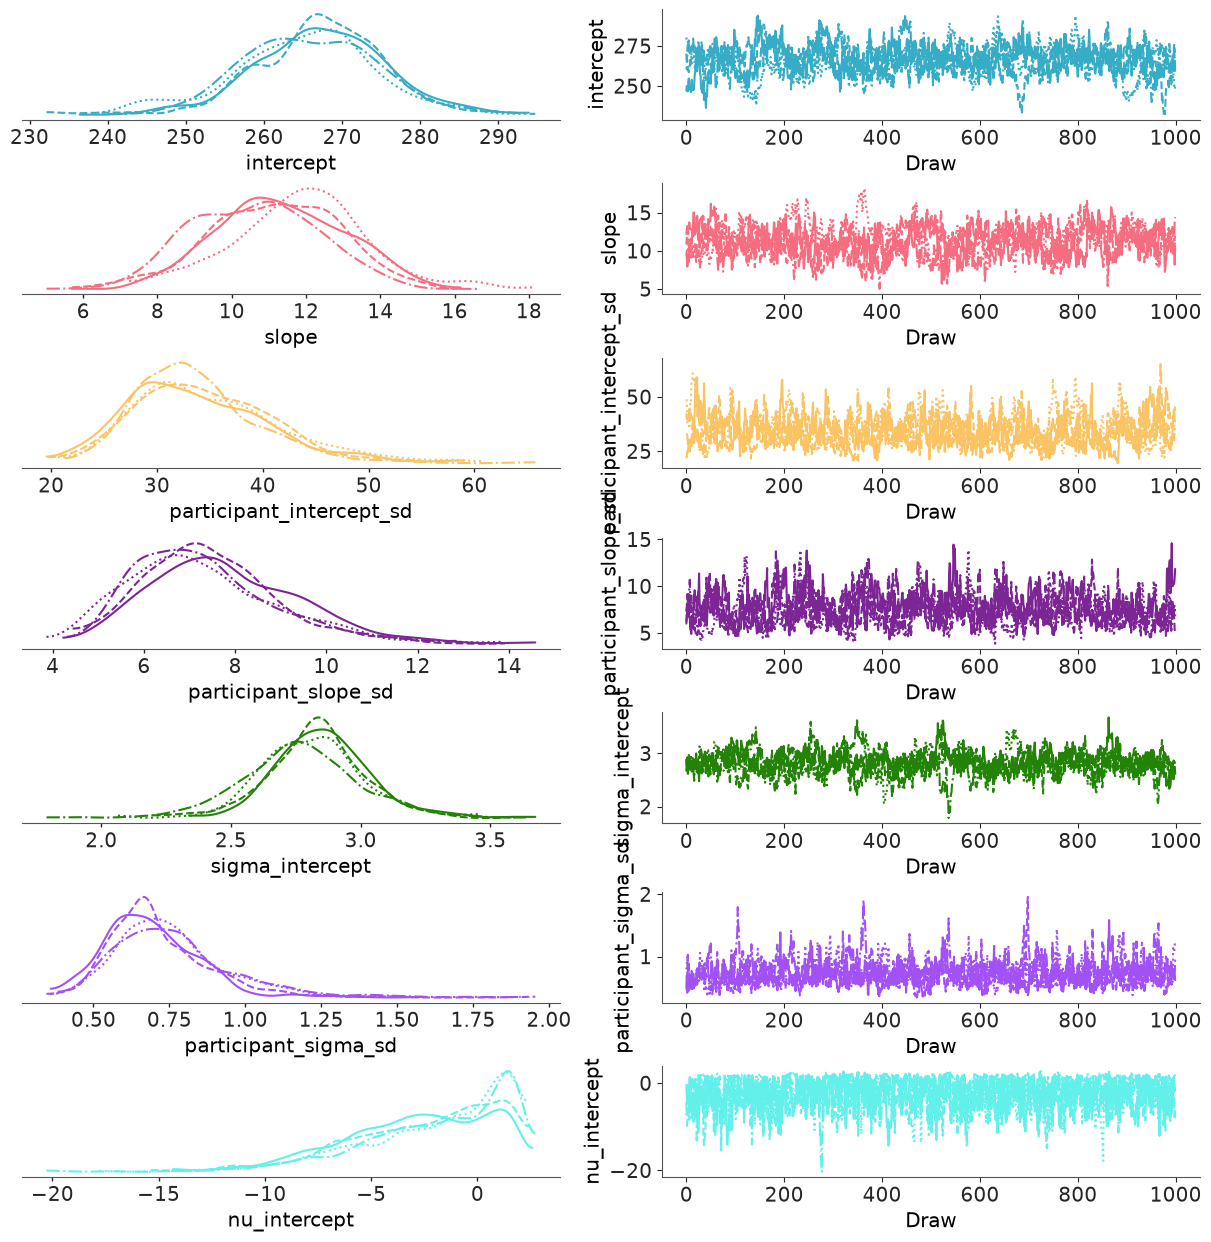

In [9]:
azp.plot_trace_dist(idata, var_names=["intercept", "slope", "participant_intercept_sd", "participant_slope_sd", "sigma_intercept", "participant_sigma_sd", "nu_intercept"]);

This plot shows posterior uncertainty in the expected reaction time (on the millisecond scale) of a *typical* participant.

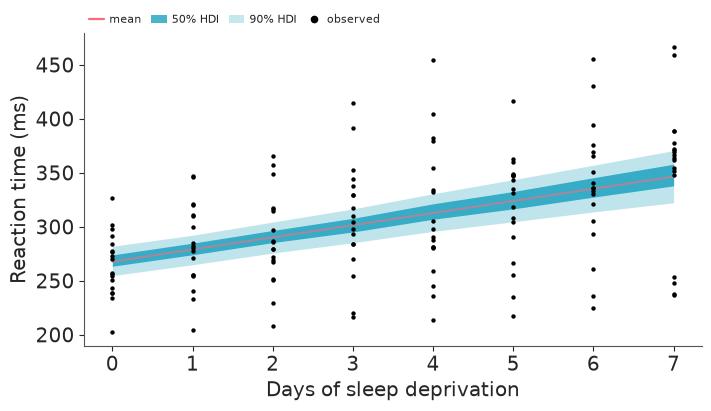

In [10]:
plot_population(idata, "population_mean_rt")
plt.show()

Each panel shows posterior uncertainty in that participant's expected reaction time.

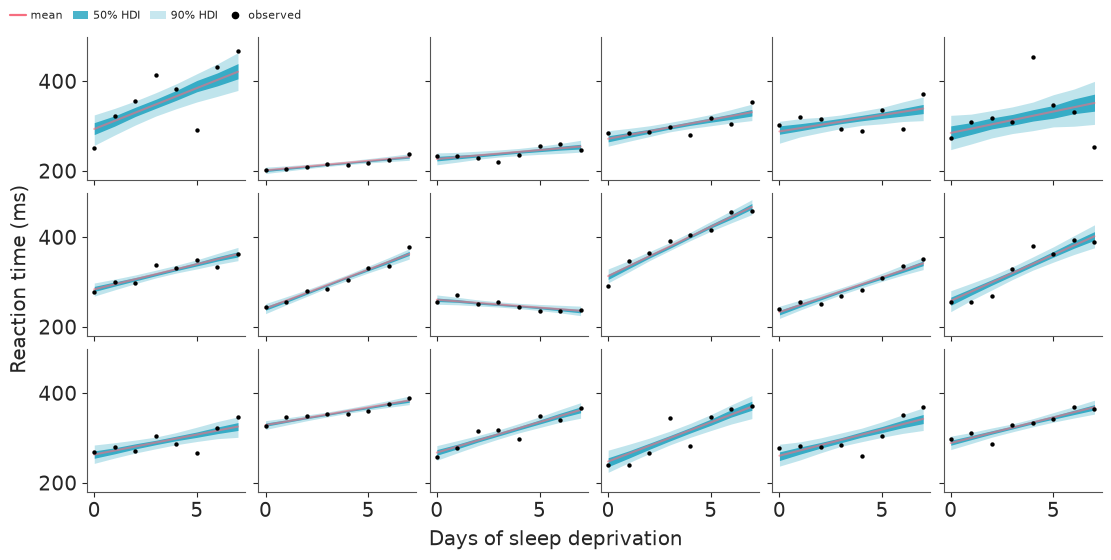

In [11]:
plot_participants(idata, "posterior", "mean_rt")
plt.show()

## 10.3 Predictive robustness to naive priors

Do the naive priors materially change the model’s predictive behavior?

Now generate new reaction times from the fitted model. The layout is the same as in the prior predictive check; the difference is that these predictions are conditioned on the data.

Sampling: [Reaction]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

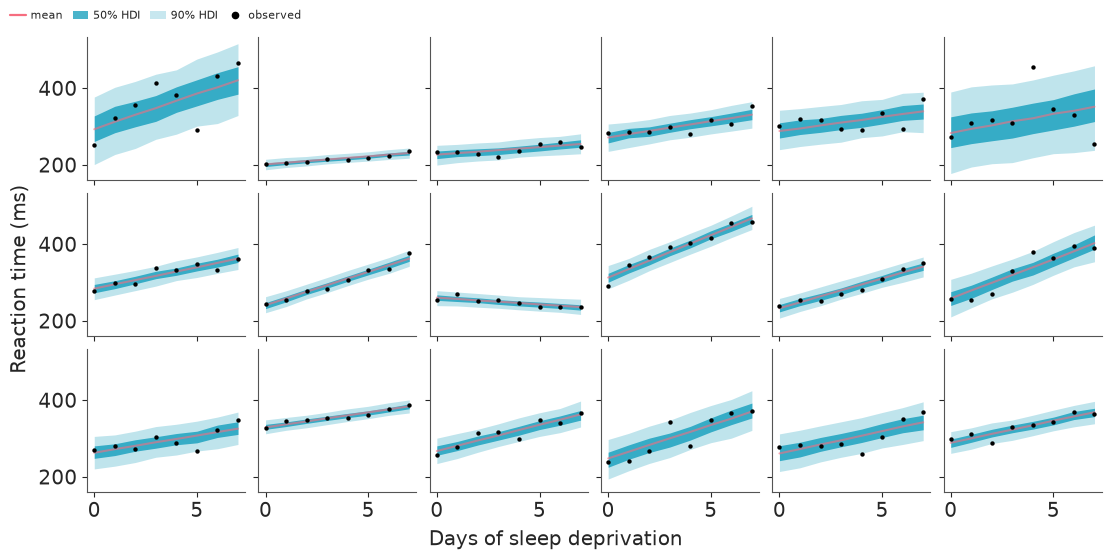

In [12]:
with model:
    pm.sample_posterior_predictive(
        idata, var_names=["Reaction"], extend_inferencedata=True, random_seed=RANDOM_SEED
    )

plot_participants(idata, "posterior_predictive", "Reaction")
plt.show()

The panel plot checks trajectories. This check pools all 144 measurements and asks whether simulated datasets reproduce the overall *shape* of the reaction-time distribution, especially its right tail.

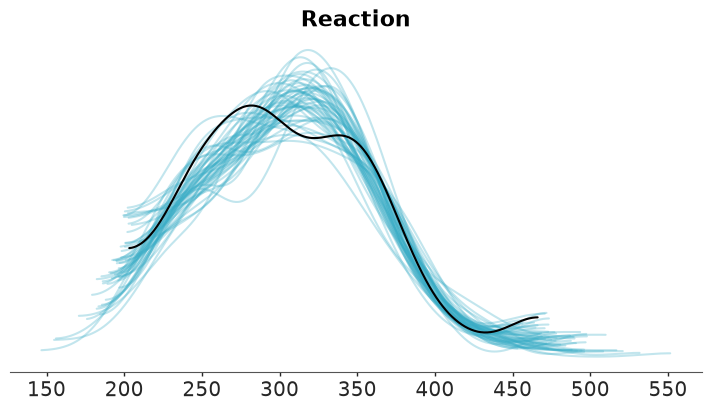

In [13]:
azp.plot_ppc_dist(idata, var_names=["Reaction"], kind="kde", figure_kwargs={"figsize": (7, 4)});

## 10.4 Parameter-level sensitivity

Which parameters appear prior-sensitive even when the overall predictions remain similar?

With this prior, sampling itself struggled (maximum tree depth on every chain, R-hat up to 1.05, ESS as low as ~170) even though the population intercept and slope landed close to notebook 9's values. That similarity is misleading: the tail parameter `nu_intercept` collapsed to a near-zero exponential component, which is a real change in what the model says about skew, not a benign one. Weak scale priors can leave a flexible likelihood's shape-defining parameters unidentified even when the mean trajectory still looks reasonable.